In [130]:
import os
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv
from langchain.tools import tool
load_dotenv()

if os.environ["GOOGLE_API_KEY"]:
    print("GOOGLE_API_KEY is set")
else:
    raise ValueError("GOOGLE_API_KEY is not set")

GOOGLE_API_KEY is set


In [131]:
from langchain_core.messages import HumanMessage,ToolMessage
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    temperature=1.0,  # Gemini 3.0+ defaults to 1.0
    max_tokens=None,
    timeout=None,
    max_retries=2,
    # other params...
)

## tools

**duclkduckgo_search**

In [132]:
from langchain_community.tools import DuckDuckGoSearchRun



@tool
def duckduckgo_search(query : str)->str:
    """this tool search for anything"""
    duckduckgo_search = DuckDuckGoSearchRun()
    return duckduckgo_search.invoke(query)


In [133]:
from langchain_community.retrievers import ArxivRetriever


@tool
def arxiv_search(query : str)->str:
    """this tool arxiv query for research paper"""
    arxiv_retriever = ArxivRetriever()
    return arxiv_retriever.invoke(query)




In [134]:
from langchain_community.retrievers import WikipediaRetriever
@tool
def wiki_tool(query : str)-> str:
    """this tool search for wikipedia"""
    wiki_retriever = WikipediaRetriever()
    docs = wiki_retriever.invoke(query)
    return docs[0].page_content



## custom tool


In [135]:

@tool
def personal_tool(name: str)->str:

    """use this tool to get personal information about a person"""

    info={
    "alice": "Alice is a person",
    "bob": "Bob is a person",
    "charlie": "Charlie is a person",
    "dave": "Dave is a person"
    }

    return info.get(name , "no info found")

In [136]:
personal_tool.invoke("alice")

'Alice is a person'

## tool binding

In [137]:
tools = [
    duckduckgo_search,personal_tool,arxiv_search,wiki_tool]

model_with_tools = model.bind_tools(tools)

In [138]:
response = model_with_tools.invoke("what is the personal info for alice")
response.tool_calls

[{'name': 'personal_tool',
  'args': {'name': 'alice'},
  'id': '6a374149-1a68-42e7-8cd1-6d17c35fc9af',
  'type': 'tool_call'}]

## langgraph creation

## create schema

In [139]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    messages: List

## create node function

In [140]:
def model_node(state: graph_schema)-> graph_schema:
    messages = state['messages']
#prompt template for the LLM, including sysytem message and human input
    prompt = ChatPromptTemplate.from_messages([
        ("system","you are a helpful assistant that can use tools to answer questions"),
        ("human","{input}")
    ])

    #llm with tool
    # model_with_tools 

    chain = prompt | model_with_tools

    response = chain.invoke({"input":messages})

    state[messages]=messages + response

    return state
    

In [141]:
# from langgraph.prebuilt import ToolNode

def tool_node(state: graph_schema) -> graph_schema:
    messages = state['messages']
    tool_by_name = {tool.name: tool for tool in tools}
    tool_result = []

    for tool in messages[-1].tool_calls:
        tool = tool_by_name[tool['name']]
        observation = tool.invoke(tool['arguments'])

        tool_result.append(ToolMessage(content=observation))

    state['messages'] = messages + tool_result



### create conditional edge function

In [ ]:


def if_tool_call(state: graph_schema) -> str:
    last_messages = state['messages'][-1]

    return "tool_node" if last_messages.tool_calls else "end"

## create state graph

In [143]:
from langgraph.graph import StateGraph,START,END

graph = StateGraph(graph_schema)


# add nodes

graph.add_node("model_node",model_node)
graph.add_node("tool_node",tool_node)


#add edges
graph.add_edge(START,"model_node")

graph.add_conditional_edges("model_node",if_tool_call,{"tool_node":"tool_node","END":END}) 

# graph.add_edge("tool_node","model_node")

graph.add_edge("model_node",END)

result_graph = graph.compile()

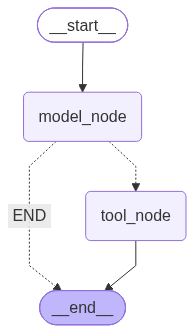

In [144]:
from IPython.display import display,Image

Image(result_graph.get_graph().draw_mermaid_png())